Filtered runs: 30

Success@k Table

model    Llama-3.1-8B-Instruct                                                                                      Phi-3.5-Mini                                                                                      Qwen2.5-Coder-7B                                                                                     
dataset              HumanEval                                          MBPP                                           HumanEval                                          MBPP                                               HumanEval                                          MBPP                                       
strategy                  FARC Planning Planning-Repair repair single   FARC Planning Planning-Repair repair single         FARC Planning Planning-Repair repair single   FARC Planning Planning-Repair repair single             FARC Planning Planning-Repair repair single   FARC Planning Planning-Repair repair single
k               

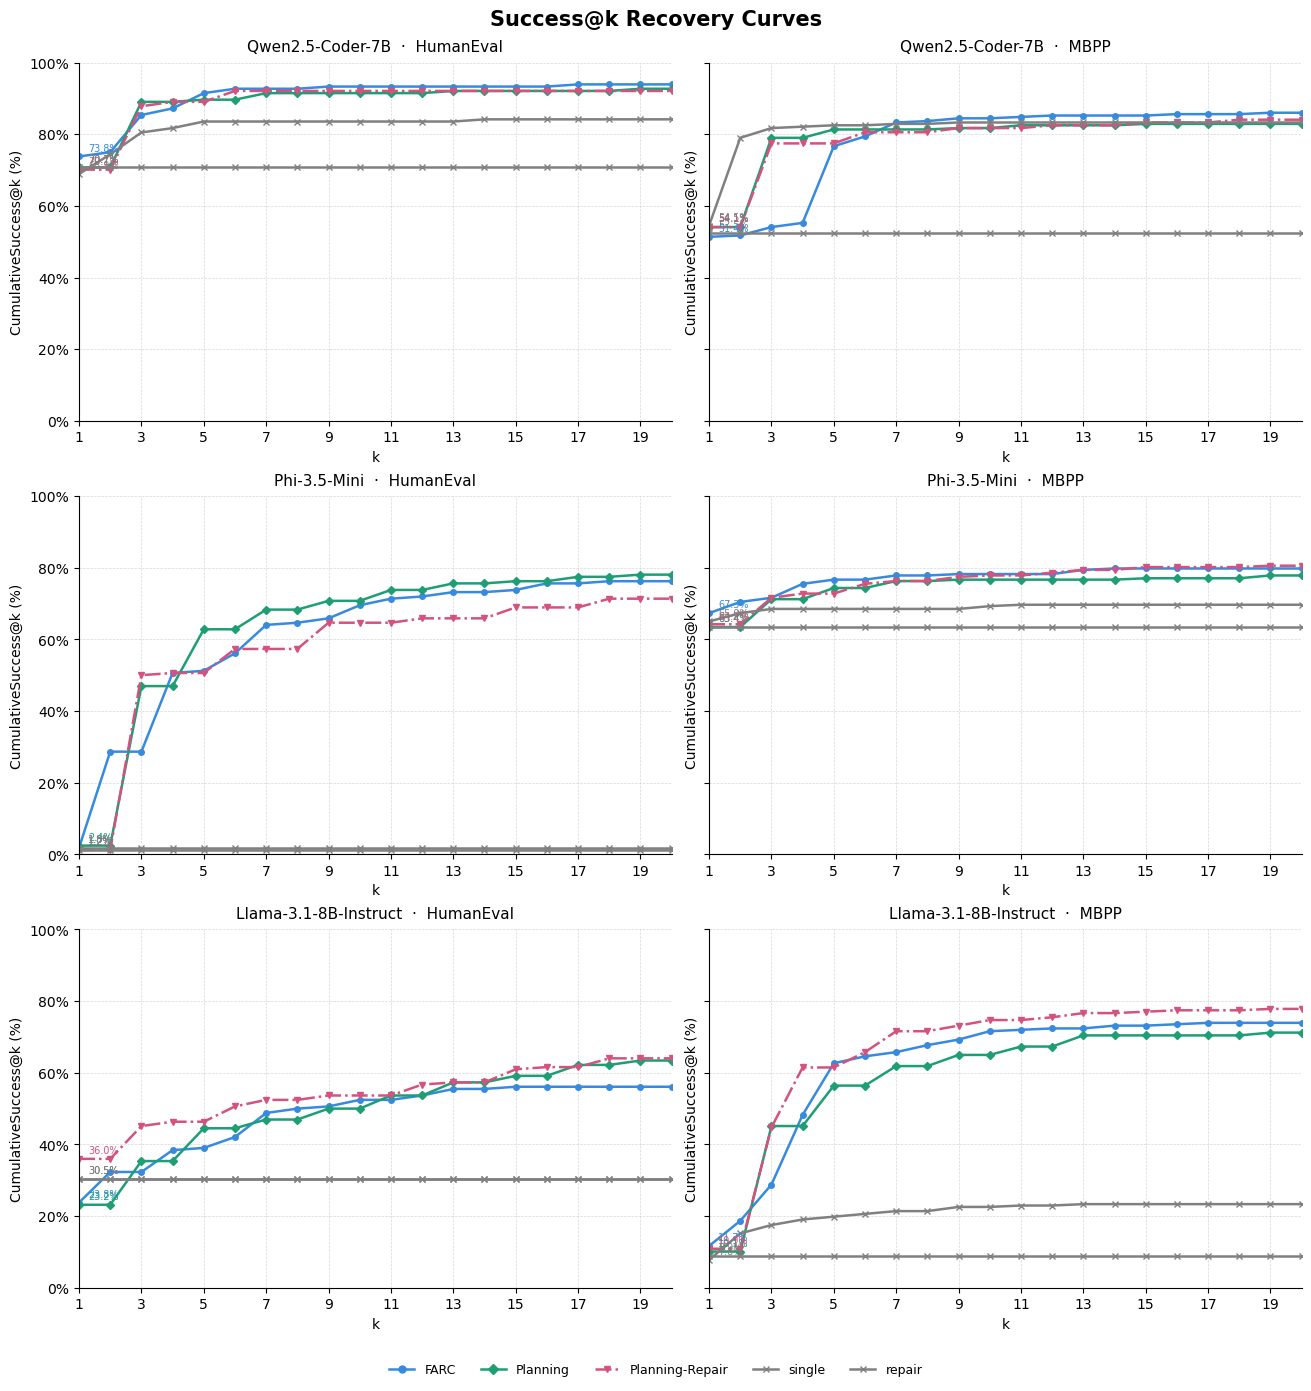

In [1]:
"""
plot_success_at_k.py  —  Jupyter / 스크립트 모두 호환

Jupyter에서:
    %run plot_success_at_k.py
    또는 셀에 붙여넣기

스크립트로:
    python plot_success_at_k.py
"""

from pathlib import Path
import json
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.lines as mlines

# ======================================================
# ★ 여기만 수정하세요
# ======================================================
RESULTS_ROOT = Path("../results")
MAX_K        = 20
OUTPUT_PATH  = None          # None → plt.show() / "figures/out.png" → 파일 저장
SHOW_TABLE   = True          # 피벗 테이블 출력 여부
# ======================================================

STRATEGY_NAME_MAP = {
    "single_shot":          "Single-shot",
    "repair_loop":          "Repair",
    "code_then_plan":       "Planning",
    "code_then_plan_repair":"Planning-Repair",
    "proposed_v1":          "FARC",
}

STRATEGY_STYLE = {
    "FARC":             {"color": "#378ADD", "ls": "-",   "marker": "o"},
    "Single-shot":      {"color": "#888780", "ls": "--",  "marker": "s"},
    "Repair":           {"color": "#D85A30", "ls": ":",   "marker": "^"},
    "Planning":         {"color": "#1D9E75", "ls": "-",   "marker": "D"},
    "Planning-Repair":  {"color": "#D4537E", "ls": "-.",  "marker": "v"},
}

MODEL_LABELS   = {"qwen25coder7b": "Qwen2.5-Coder-7B", "phi35mini": "Phi-3.5-Mini", "llama318b": "Llama-3.1-8B-Instruct"}
DATASET_LABELS = {"humaneval": "HumanEval", "mbpp": "MBPP"}

PANEL_LAYOUT = [
    ("qwen25coder7b", "humaneval"),
    ("qwen25coder7b", "mbpp"),
    ("phi35mini",     "humaneval"),
    ("phi35mini",     "mbpp"),
    ("llama318b",     "humaneval"),
    ("llama318b",     "mbpp"),
]


# --------------------------------------------------
def discover_runs(results_root):
    runs = []
    for traj_path in results_root.rglob("trajectory_logs.jsonl"):
        parts = traj_path.parent.relative_to(results_root).parts
        if len(parts) < 3:
            continue
        model, dataset, strategy = parts[:3]
        runs.append({"model": model, "dataset": dataset,
                     "strategy": strategy, "trajectory_path": traj_path})
    return runs


def read_jsonl(path):
    rows = []
    with open(path, "r", encoding="utf-8") as f:
        for line in f:
            line = line.strip()
            if line:
                rows.append(json.loads(line))
    return rows


def compute_success_curve(rows, max_k):
    total = len(rows)
    return [
        sum(1 for r in rows if r["final_status"] == "PASS" and r["call_count"] <= k)
        / total * 100
        for k in range(1, max_k + 1)
    ]


def collect_curves(results_root, max_k):
    runs = discover_runs(results_root)
    filtered = [
        r for r in runs
        if r["dataset"] in ("humaneval", "mbpp")
        and ("qwen25coder7b" in r["model"] or "phi35mini" in r["model"] or "llama318b" in r["model"])
        and "proposed_v2" not in r["strategy"]
        and "proposed_v3" not in r["strategy"]
    ]
    print(f"Filtered runs: {len(filtered)}")

    curves = {}
    for run in filtered:
        key    = (run["model"], run["dataset"])
        pretty = STRATEGY_NAME_MAP.get(run["strategy"], run["strategy"])
        rows   = read_jsonl(run["trajectory_path"])
        curves.setdefault(key, {})[pretty] = compute_success_curve(rows, max_k)
    return curves


# --------------------------------------------------
def plot_all(curves, max_k, output_path):
    k_vals = list(range(1, max_k + 1))

    # 행별로 y축 공유
    fig, axes = plt.subplots(3, 2, figsize=(13, 13), sharey='row', constrained_layout=True)
    fig.suptitle("Success@k Recovery Curves", fontsize=15, fontweight="bold", y=1.02)

    legend_handles = {}

    for idx, (model, dataset) in enumerate(PANEL_LAYOUT):
        row, col = divmod(idx, 2)
        ax = axes[row][col]
        strats = curves.get((model, dataset), {})

        ordered = [s for s in STRATEGY_STYLE if s in strats]
        ordered += [s for s in strats if s not in ordered]

        for strategy in ordered:
            values = strats[strategy]
            style  = STRATEGY_STYLE.get(strategy, {"color": "gray", "ls": "-", "marker": "x"})

            ax.plot(
                k_vals[:len(values)], values,
                color=style["color"], linestyle=style["ls"],
                marker=style["marker"], markersize=4,
                linewidth=1.8, label=strategy,
            )
            if values:
                ax.annotate(
                    f"{values[0]:.1f}%",
                    xy=(1, values[0]), xytext=(1.3, values[0] + 1.5),
                    fontsize=7, color=style["color"],
                )

            if strategy not in legend_handles:
                legend_handles[strategy] = mlines.Line2D(
                    [], [], color=style["color"], linestyle=style["ls"],
                    marker=style["marker"], markersize=5, linewidth=1.8, label=strategy,
                )

        ax.set_title(
            f"{MODEL_LABELS.get(model, model)}  ·  {DATASET_LABELS.get(dataset, dataset)}",
            fontsize=11, pad=8,
        )
        ax.set_xlabel("k", fontsize=10)
        ax.set_ylabel("CumulativeSuccess@k (%)", fontsize=10)
        ax.set_xlim(1, max_k)
        ax.set_ylim(0, 100)
        ax.set_xticks(range(1, max_k + 1, 2))
        ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{v:.0f}%"))
        ax.grid(True, linestyle="--", linewidth=0.5, alpha=0.5)
        ax.spines[["top", "right"]].set_visible(False)

    fig.legend(
        handles=list(legend_handles.values()),
        loc="lower center", ncol=len(legend_handles),
        fontsize=9, frameon=False, bbox_to_anchor=(0.5, -0.04),
    )

    if output_path:
        Path(output_path).parent.mkdir(parents=True, exist_ok=True)
        fig.savefig(output_path, dpi=150, bbox_inches="tight")
        print(f"Saved → {output_path}")

    plt.show()


# --------------------------------------------------
def print_table(curves, max_k):
    k_vals = list(range(1, max_k + 1))
    rows = []
    for (model, dataset), strats in curves.items():
        for strategy, values in strats.items():
            for i, v in enumerate(values[:max_k]):
                rows.append({
                    "model":    MODEL_LABELS.get(model, model),
                    "dataset":  DATASET_LABELS.get(dataset, dataset),
                    "strategy": strategy,
                    "k":        k_vals[i],
                    "success_rate": f"{v:.1f}%",
                })
    pivot = (
        pd.DataFrame(rows)
        .pivot_table(index="k", columns=["model", "dataset", "strategy"],
                     values="success_rate", aggfunc="first")
    )
    print("\nSuccess@k Table\n")
    print(pivot.to_string())
# --------------------------------------------------
def compute_ausc(values):
    return sum(values) / len(values)


def print_summary_table(curves):
    rows = []

    for (model, dataset), strats in curves.items():
        for strategy, values in strats.items():

            success20 = values[-1]
            ausc      = compute_ausc(values)

            rows.append({
                "Model": MODEL_LABELS.get(model, model),
                "Dataset": DATASET_LABELS.get(dataset, dataset),
                "Strategy": strategy,
                "Success@20": f"{success20:.1f}%",
                "AUSC": f"{ausc:.2f}",
            })

    df = pd.DataFrame(rows)

    print("\nMain Results Table\n")
    print(df.to_string(index=False))

# --------------------------------------------------
# 실행 (argparse 없음 — Jupyter 호환)
# --------------------------------------------------
curves = collect_curves(RESULTS_ROOT, MAX_K)

if SHOW_TABLE:
    print_table(curves, MAX_K)
    print_summary_table(curves)

plot_all(curves, MAX_K, OUTPUT_PATH)


In [2]:
# --------------------------------------------------
# Convert curves -> reusable DATA dictionary
# --------------------------------------------------

DATA = {}

for (model, dataset), strats in curves.items():

    model_name = MODEL_LABELS.get(model, model)
    dataset_name = DATASET_LABELS.get(dataset, dataset)

    DATA[(model_name, dataset_name)] = {}

    for strategy, values in strats.items():

        strategy_name = strategy

        # optional rename
        if strategy_name == "single":
            strategy_name = "Single-shot"
        elif strategy_name == "repair":
            strategy_name = "Repair"
        elif strategy_name == "code_then_plan":
            strategy_name = "Planning"
        elif strategy_name == "code_then_plan_repair":
            strategy_name = "Planning-Repair"
        elif strategy_name == "proposed_v1":
            strategy_name = "FARC"

        DATA[(model_name, dataset_name)][strategy_name] = [
            round(v, 1) for v in values[:MAX_K]
        ]


---

/tmp/ipykernel_1026255/2411870646.py:159: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


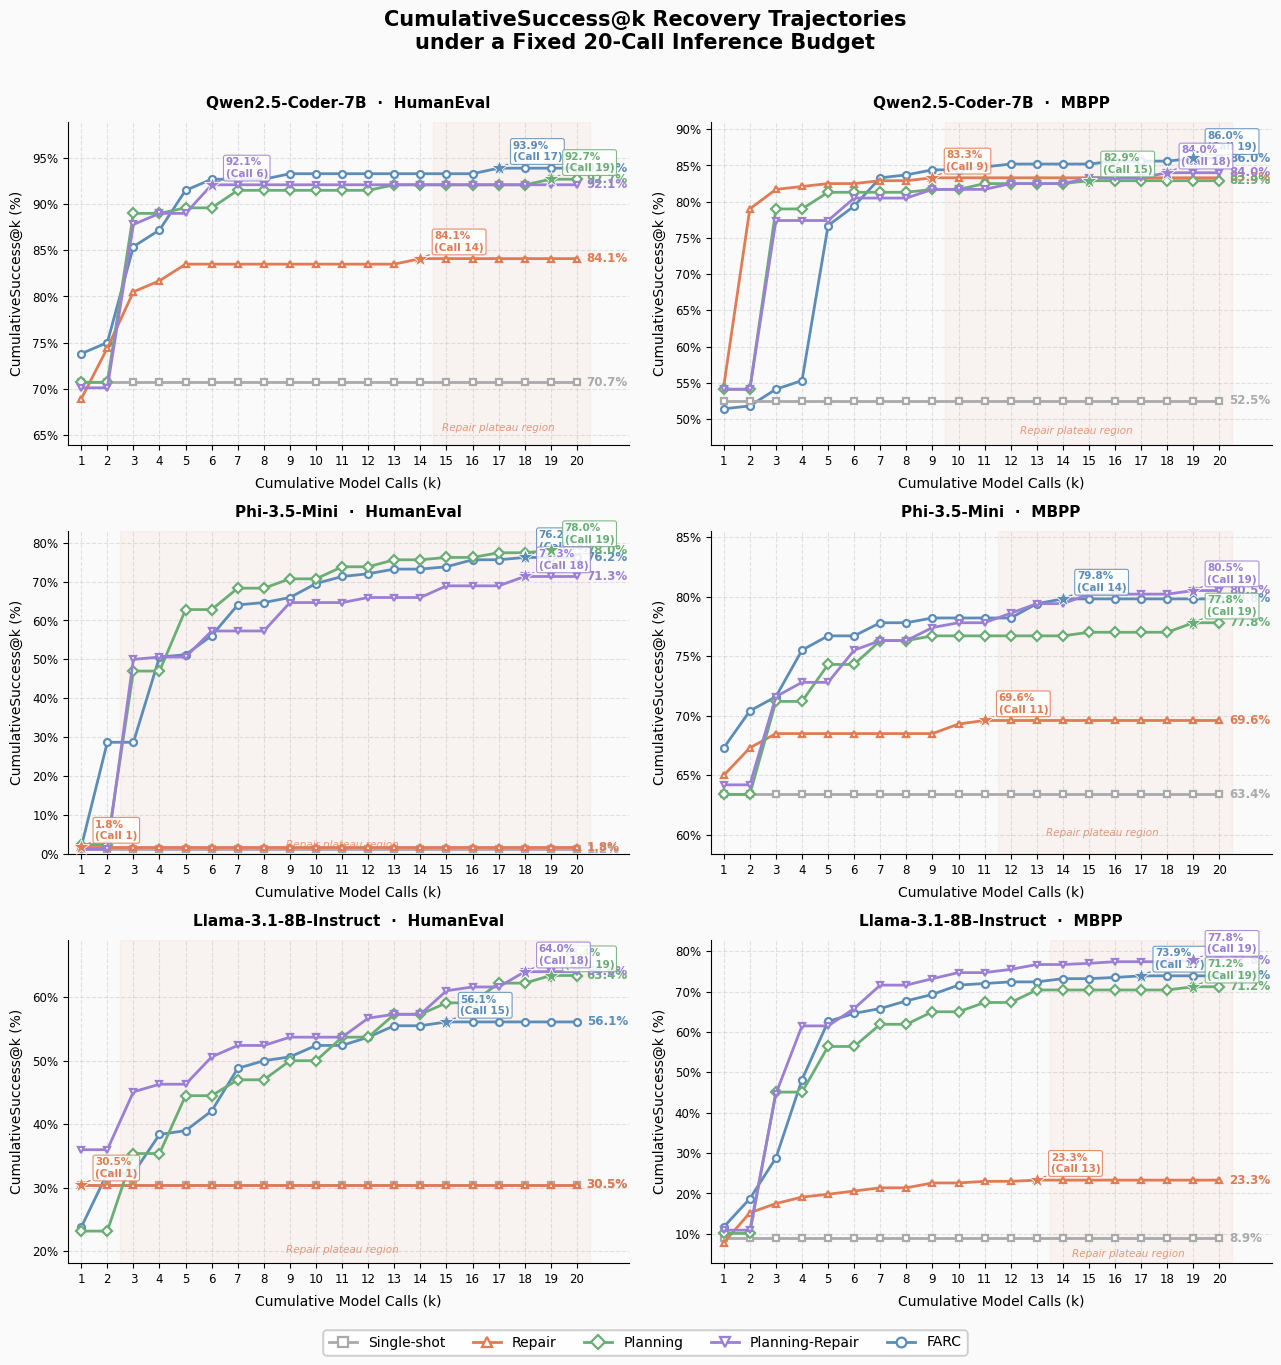

저장 완료: ./archive/section5_2_success_at_k_panels.png


In [3]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

# ── 데이터 ────────────────────────────────────────────────────────────────
DATA

# ── 스타일 ────────────────────────────────────────────────────────────────
STYLE = {
    "FARC":            {"color": "#5B8DB8", "marker": "o"},
    "Single-shot":     {"color": "#AAAAAA", "marker": "s"},
    "Repair":          {"color": "#E07B54", "marker": "^"},
    "Planning":        {"color": "#6BAE75", "marker": "D"},
    "Planning-Repair": {"color": "#9B7FD4", "marker": "v"},
}

PANEL_LAYOUT = [
    ("Qwen2.5-Coder-7B", "HumanEval"),
    ("Qwen2.5-Coder-7B", "MBPP"),
    ("Phi-3.5-Mini",     "HumanEval"),
    ("Phi-3.5-Mini",     "MBPP"),
    ("Llama-3.1-8B-Instruct",     "HumanEval"),
    ("Llama-3.1-8B-Instruct",     "MBPP"),
    
]

steps = list(range(1, 21))
LEGEND_ORDER = ["Single-shot", "Repair", "Planning", "Planning-Repair", "FARC"]

# ── Figure ────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(3, 2, figsize=(13, 13), sharey=False, constrained_layout=True)
fig.patch.set_facecolor("#FAFAFA")
fig.suptitle(
    "CumulativeSuccess@k Recovery Trajectories\nunder a Fixed 20-Call Inference Budget",
    fontsize=15, fontweight="bold", y=1.01,
)

for idx, (model, dataset) in enumerate(PANEL_LAYOUT):
    row, col = divmod(idx, 2)
    ax = axes[row][col]
    ax.set_facecolor("#FAFAFA")

    strats = DATA[(model, dataset)]

    # y축 범위 자동 계산
    all_vals = [v for vals in strats.values() for v in vals]
    y_min = max(0,   min(all_vals) - 5)
    y_max = min(100, max(all_vals) + 5)

    # Repair plateau 음영
    if "Repair" in strats:
        repair_vals = strats["Repair"]
        plateau_start = next(
            (i + 1 for i in range(1, len(repair_vals)) if repair_vals[i] == repair_vals[-1]),
            len(repair_vals),
        )
        ax.axvspan(plateau_start + 0.5, 20.5, alpha=0.06, color="#E07B54", zorder=1)
        ax.text(
            (plateau_start + 20) / 2, y_min + 1.5,
            "Repair plateau region",
            ha="center", fontsize=7.5, color="#E07B54", alpha=0.75, style="italic",
        )

    # 라인 플롯
    for label, values in strats.items():
        s = STYLE.get(label, {"color": "gray", "marker": "x"})
        ax.plot(
            steps, values,
            color=s["color"],
            linestyle="-",
            linewidth=2.0,
            marker=s["marker"],
            markersize=5,
            markerfacecolor="white",
            markeredgewidth=1.6,
            markeredgecolor=s["color"],
            label=label,
            zorder=3,
        )
        # 라인 끝 최종값 레이블
        ax.annotate(
            f"{values[-1]:.1f}%",
            xy=(20, values[-1]),
            xytext=(7, 0),
            textcoords="offset points",
            va="center",
            fontsize=8.5,
            fontweight="bold",
            color=s["color"],
        )

    # milestone: 각 전략의 값이 처음으로 최종값에 도달하는 step에 ★ 표시
    for label, values in strats.items():
        if label in ("Single-shot",):   # flat 전략은 스킵
            continue
        final = values[-1]
        milestone_step = next(
            (i + 1 for i, v in enumerate(values) if v >= final), len(values)
        )
        # 최종 step이면 스킵 (특별히 강조할 변화 없음)
        if milestone_step == 20:
            continue
        s = STYLE.get(label, {"color": "gray", "marker": "x"})
        ax.plot(milestone_step, values[milestone_step - 1],
                marker="*", markersize=12,
                color=s["color"], zorder=5,
                markeredgecolor="white", markeredgewidth=0.6)
        ax.annotate(
            f"{values[milestone_step - 1]:.1f}%\n(Call {milestone_step})",
            xy=(milestone_step, values[milestone_step - 1]),
            xytext=(10, 12),
            textcoords="offset points",
            fontsize=7.5,
            color=s["color"],
            fontweight="bold",
            arrowprops=dict(arrowstyle="-", color=s["color"], lw=1.0),
            va="center",
            bbox=dict(boxstyle="round,pad=0.2", fc="white",
                      ec=s["color"], alpha=0.85, lw=0.8),
        )

    # 축 설정
    ax.set_xlim(0.5, 22)
    ax.set_ylim(y_min, y_max)
    ax.set_xticks(steps)
    ax.set_xticklabels([str(s) for s in steps], fontsize=8)
    ax.set_xlabel("Cumulative Model Calls (k)", fontsize=10, labelpad=6)
    ax.set_ylabel("CumulativeSuccess@k (%)", fontsize=10, labelpad=6)
    ax.set_title(f"{model}  ·  {dataset}", fontsize=11, fontweight="bold", pad=10)
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:.0f}%"))
    ax.grid(True, linestyle="--", alpha=0.35, zorder=0)
    ax.tick_params(axis="both", labelsize=8.5)
    ax.spines[["top", "right"]].set_visible(False)

    # 공통 범례 (루프 밖)
    handles = [
        plt.Line2D([0], [0],
                color=STYLE[label]["color"],
                marker=STYLE[label]["marker"],
                markersize=7,
                markerfacecolor="white",
                markeredgewidth=1.6,
                markeredgecolor=STYLE[label]["color"],
                linewidth=2.0,
                label=label)
        for label in LEGEND_ORDER
    ]

    fig.legend(
        handles=handles,
        loc="lower center",
        ncol=len(LEGEND_ORDER),
        fontsize=10,
        frameon=True,
        framealpha=0.9,
        edgecolor="#CCCCCC",
        bbox_to_anchor=(0.5, -0.03),
    )

plt.tight_layout()
plt.savefig("./archive/section5_2_success_at_k_panels.png", dpi=150, bbox_inches="tight")
plt.show()
print("저장 완료: ./archive/section5_2_success_at_k_panels.png")

/tmp/ipykernel_1026255/4096943828.py:210: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


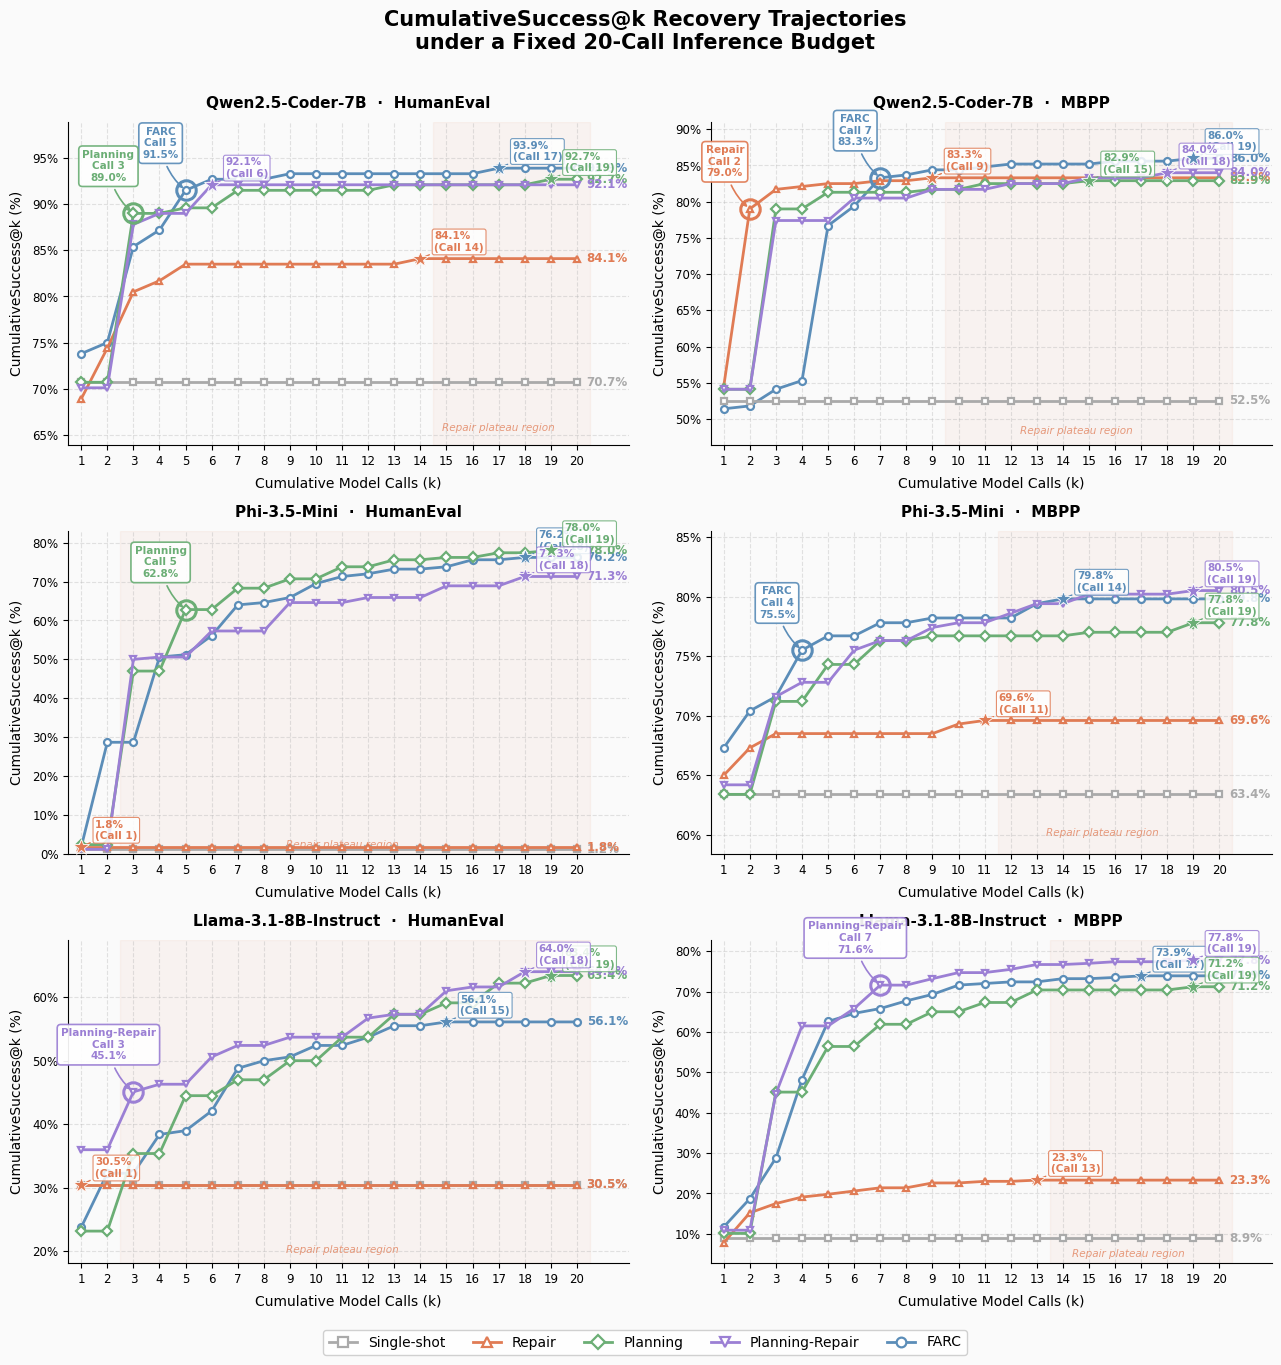

저장 완료: ./archive/section5_2_success_at_k_panels.png


In [8]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

# ── 데이터 ────────────────────────────────────────────────────────────────
DATA

# ── 스타일 ────────────────────────────────────────────────────────────────
STYLE = {
    "FARC":            {"color": "#5B8DB8", "marker": "o"},
    "Single-shot":     {"color": "#AAAAAA", "marker": "s"},
    "Repair":          {"color": "#E07B54", "marker": "^"},
    "Planning":        {"color": "#6BAE75", "marker": "D"},
    "Planning-Repair": {"color": "#9B7FD4", "marker": "v"},
}

PANEL_LAYOUT = [
    ("Qwen2.5-Coder-7B", "HumanEval"),
    ("Qwen2.5-Coder-7B", "MBPP"),
    ("Phi-3.5-Mini",     "HumanEval"),
    ("Phi-3.5-Mini",     "MBPP"),
    ("Llama-3.1-8B-Instruct",     "HumanEval"),
    ("Llama-3.1-8B-Instruct",     "MBPP"),
]

steps = list(range(1, 21))
LEGEND_ORDER = ["Single-shot", "Repair", "Planning", "Planning-Repair", "FARC"]

# ── 커스텀 말풍선 마크 정의 ───────────────────────────────────────────────
# { (model, dataset): [ (strategy, step), ... ] }
CUSTOM_MARKS = {
    ("Qwen2.5-Coder-7B",      "HumanEval"): [("FARC", 5),     ("Planning", 3)],
    ("Qwen2.5-Coder-7B",      "MBPP"):      [("Repair", 2),   ("FARC", 7)],
    ("Phi-3.5-Mini",          "HumanEval"): [("Planning", 5)],
    ("Phi-3.5-Mini",          "MBPP"):      [("FARC", 4)],
    ("Llama-3.1-8B-Instruct", "HumanEval"): [("Planning-Repair", 3)],
    ("Llama-3.1-8B-Instruct", "MBPP"):      [("Planning-Repair", 7)],
}

# ── Figure ────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(3, 2, figsize=(13, 13), sharey=False, constrained_layout=True)
fig.patch.set_facecolor("#FAFAFA")
fig.suptitle(
    "CumulativeSuccess@k Recovery Trajectories\nunder a Fixed 20-Call Inference Budget",
    fontsize=15, fontweight="bold", y=1.01,
)

for idx, (model, dataset) in enumerate(PANEL_LAYOUT):
    row, col = divmod(idx, 2)
    ax = axes[row][col]
    ax.set_facecolor("#FAFAFA")

    strats = DATA[(model, dataset)]

    # y축 범위 자동 계산
    all_vals = [v for vals in strats.values() for v in vals]
    y_min = max(0,   min(all_vals) - 5)
    y_max = min(100, max(all_vals) + 5)

    # Repair plateau 음영
    if "Repair" in strats:
        repair_vals = strats["Repair"]
        plateau_start = next(
            (i + 1 for i in range(1, len(repair_vals)) if repair_vals[i] == repair_vals[-1]),
            len(repair_vals),
        )
        ax.axvspan(plateau_start + 0.5, 20.5, alpha=0.06, color="#E07B54", zorder=1)
        ax.text(
            (plateau_start + 20) / 2, y_min + 1.5,
            "Repair plateau region",
            ha="center", fontsize=7.5, color="#E07B54", alpha=0.75, style="italic",
        )

    # 라인 플롯
    for label, values in strats.items():
        s = STYLE.get(label, {"color": "gray", "marker": "x"})
        ax.plot(
            steps, values,
            color=s["color"],
            linestyle="-",
            linewidth=2.0,
            marker=s["marker"],
            markersize=5,
            markerfacecolor="white",
            markeredgewidth=1.6,
            markeredgecolor=s["color"],
            label=label,
            zorder=3,
        )
        # 라인 끝 최종값 레이블
        ax.annotate(
            f"{values[-1]:.1f}%",
            xy=(20, values[-1]),
            xytext=(7, 0),
            textcoords="offset points",
            va="center",
            fontsize=8.5,
            fontweight="bold",
            color=s["color"],
        )

    # milestone: 각 전략의 값이 처음으로 최종값에 도달하는 step에 ★ 표시
    for label, values in strats.items():
        if label in ("Single-shot",):
            continue
        final = values[-1]
        milestone_step = next(
            (i + 1 for i, v in enumerate(values) if v >= final), len(values)
        )
        if milestone_step == 20:
            continue
        s = STYLE.get(label, {"color": "gray", "marker": "x"})
        ax.plot(milestone_step, values[milestone_step - 1],
                marker="*", markersize=12,
                color=s["color"], zorder=5,
                markeredgecolor="white", markeredgewidth=0.6)
        ax.annotate(
            f"{values[milestone_step - 1]:.1f}%\n(Call {milestone_step})",
            xy=(milestone_step, values[milestone_step - 1]),
            xytext=(10, 12),
            textcoords="offset points",
            fontsize=7.5,
            color=s["color"],
            fontweight="bold",
            arrowprops=dict(arrowstyle="-", color=s["color"], lw=1.0),
            va="center",
            bbox=dict(boxstyle="round,pad=0.2", fc="white",
                      ec=s["color"], alpha=0.85, lw=0.8),
        )

    # ── 커스텀 말풍선 마크 ────────────────────────────────────────────────
    for (label, step) in CUSTOM_MARKS.get((model, dataset), []):
        if label not in strats:
            continue
        val = strats[label][step - 1]   # step은 1-based
        s = STYLE.get(label, {"color": "gray", "marker": "x"})

        # 강조 원형 마크
        ax.plot(step, val,
                marker="o", markersize=14,
                color=s["color"], zorder=6,
                markerfacecolor="none",
                markeredgewidth=2.2,
                markeredgecolor=s["color"])

        # 말풍선 텍스트: "전략명\nStep k\n값%"
        ax.annotate(
            f"{label}\nCall {step}\n{val:.1f}%",
            xy=(step, val),
            xytext=(-18, 22),
            textcoords="offset points",
            fontsize=7.5,
            color=s["color"],
            fontweight="bold",
            ha="center",
            va="bottom",
            arrowprops=dict(
                arrowstyle="->",
                color=s["color"],
                lw=1.2,
                connectionstyle="arc3,rad=0.2",
            ),
            bbox=dict(
                boxstyle="round,pad=0.35",
                fc="white",
                ec=s["color"],
                alpha=0.92,
                lw=1.2,
            ),
            zorder=7,
        )

    # 축 설정
    ax.set_xlim(0.5, 22)
    ax.set_ylim(y_min, y_max)
    ax.set_xticks(steps)
    ax.set_xticklabels([str(s) for s in steps], fontsize=8)
    ax.set_xlabel("Cumulative Model Calls (k)", fontsize=10, labelpad=6)
    ax.set_ylabel("CumulativeSuccess@k (%)", fontsize=10, labelpad=6)
    ax.set_title(f"{model}  ·  {dataset}", fontsize=11, fontweight="bold", pad=10)
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:.0f}%"))
    ax.grid(True, linestyle="--", alpha=0.35, zorder=0)
    ax.tick_params(axis="both", labelsize=8.5)
    ax.spines[["top", "right"]].set_visible(False)

# ── 공통 범례 (루프 밖) ───────────────────────────────────────────────────
handles = [
    plt.Line2D([0], [0],
            color=STYLE[label]["color"],
            marker=STYLE[label]["marker"],
            markersize=7,
            markerfacecolor="white",
            markeredgewidth=1.6,
            markeredgecolor=STYLE[label]["color"],
            linewidth=2.0,
            label=label)
    for label in LEGEND_ORDER
]

fig.legend(
    handles=handles,
    loc="lower center",
    ncol=len(LEGEND_ORDER),
    fontsize=10,
    frameon=True,
    framealpha=0.9,
    edgecolor="#CCCCCC",
    bbox_to_anchor=(0.5, -0.03),
)

plt.tight_layout()
plt.savefig("./archive/section5_2_success_at_k_panels.png", dpi=150, bbox_inches="tight")
plt.show()
print("저장 완료: ./archive/section5_2_success_at_k_panels.png")

/tmp/ipykernel_1026255/1474432111.py:188: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


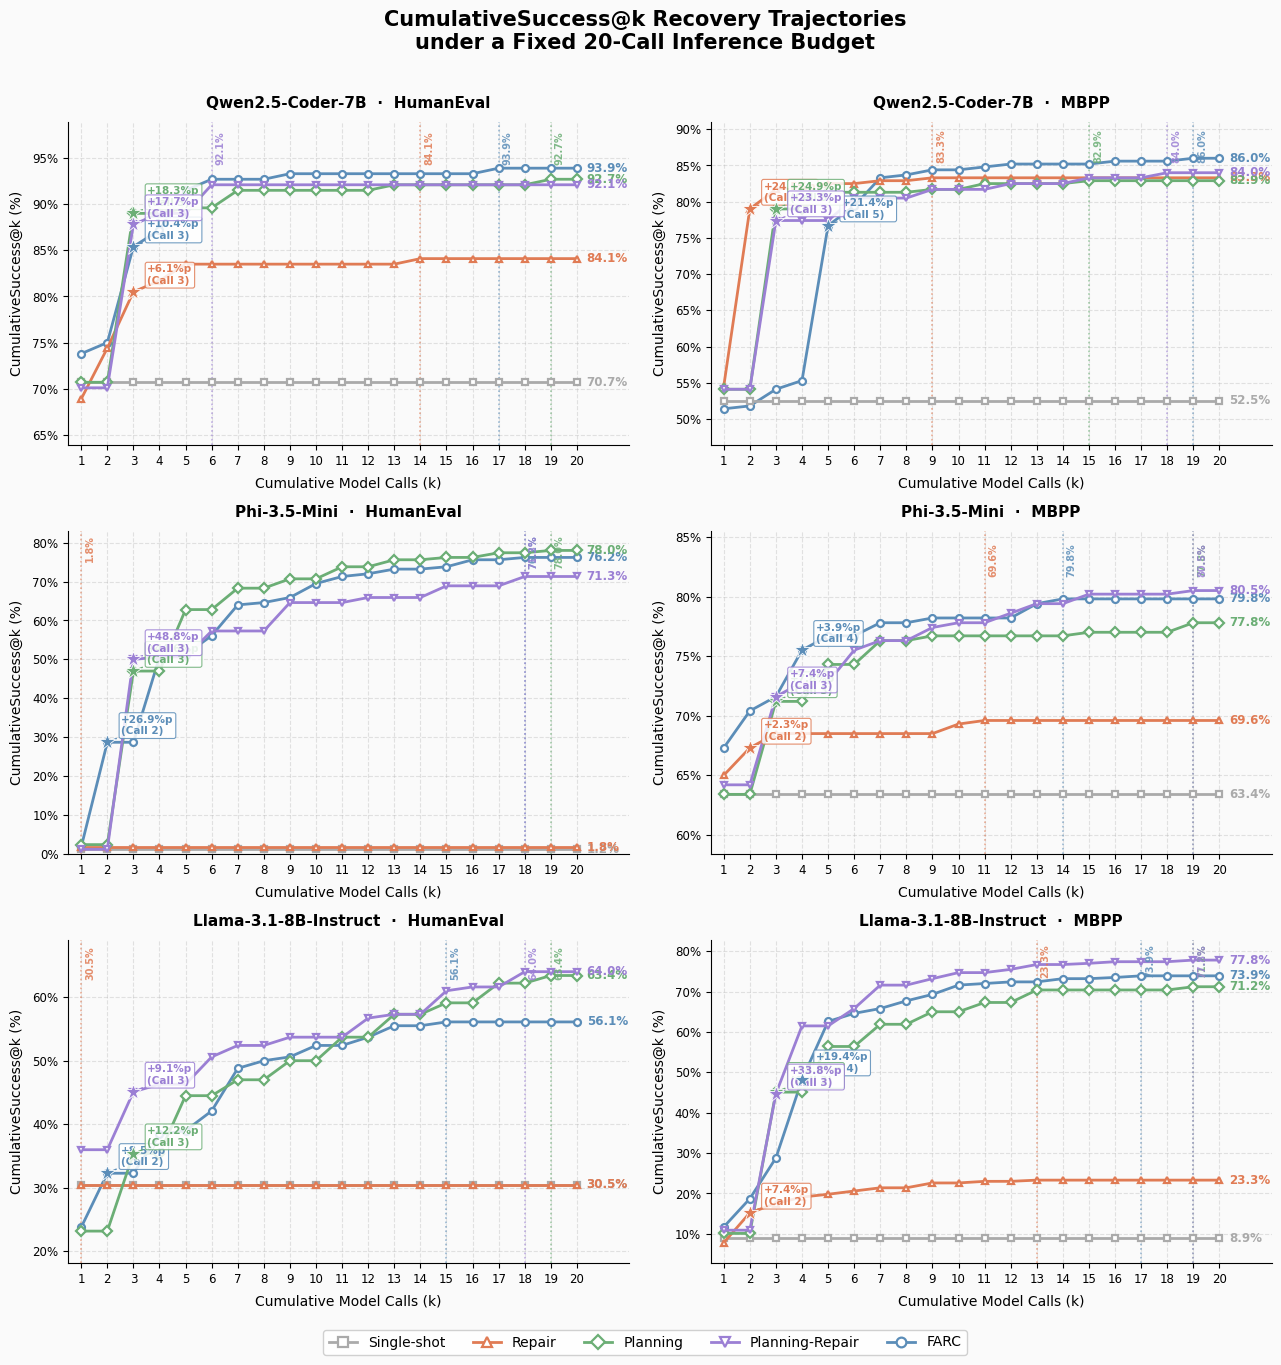

저장 완료: ./archive/success_at_k_panels.png


In [5]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

# ── 데이터 ────────────────────────────────────────────────────────────────
DATA

# ── 스타일 ────────────────────────────────────────────────────────────────
STYLE = {
    "FARC":            {"color": "#5B8DB8", "marker": "o"},
    "Single-shot":     {"color": "#AAAAAA", "marker": "s"},
    "Repair":          {"color": "#E07B54", "marker": "^"},
    "Planning":        {"color": "#6BAE75", "marker": "D"},
    "Planning-Repair": {"color": "#9B7FD4", "marker": "v"},
}

PANEL_LAYOUT = [
    ("Qwen2.5-Coder-7B", "HumanEval"),
    ("Qwen2.5-Coder-7B", "MBPP"),
    ("Phi-3.5-Mini",     "HumanEval"),
    ("Phi-3.5-Mini",     "MBPP"),
    ("Llama-3.1-8B-Instruct", "HumanEval"),
    ("Llama-3.1-8B-Instruct", "MBPP"),
]

LEGEND_ORDER = ["Single-shot", "Repair", "Planning", "Planning-Repair", "FARC"]

steps = list(range(1, 21))

# ── Figure ────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(3, 2, figsize=(13, 13), sharey=False, constrained_layout=True)
fig.patch.set_facecolor("#FAFAFA")
fig.suptitle(
    "CumulativeSuccess@k Recovery Trajectories\nunder a Fixed 20-Call Inference Budget",
    fontsize=15, fontweight="bold", y=1.01,
)

for idx, (model, dataset) in enumerate(PANEL_LAYOUT):
    row, col = divmod(idx, 2)
    ax = axes[row][col]
    ax.set_facecolor("#FAFAFA")

    strats = DATA[(model, dataset)]

    # y축 범위 자동 계산
    all_vals = [v for vals in strats.values() for v in vals]
    y_min = max(0,   min(all_vals) - 5)
    y_max = min(100, max(all_vals) + 5)

    # 라인 플롯
    for label, values in strats.items():
        s = STYLE.get(label, {"color": "gray", "marker": "x"})
        ax.plot(
            steps, values,
            color=s["color"],
            linestyle="-",
            linewidth=2.0,
            marker=s["marker"],
            markersize=5,
            markerfacecolor="white",
            markeredgewidth=1.6,
            markeredgecolor=s["color"],
            label=label,
            zorder=3,
        )
        # 라인 끝 최종값 레이블
        ax.annotate(
            f"{values[-1]:.1f}%",
            xy=(20, values[-1]),
            xytext=(7, 0),
            textcoords="offset points",
            va="center",
            fontsize=8.5,
            fontweight="bold",
            color=s["color"],
        )

    # 최대 증가폭: ★ 마커 + 말풍선 + step 번호
    for label, values in strats.items():
        diffs = [values[i] - values[i-1] for i in range(1, len(values))]
        max_diff = max(diffs)

        if max_diff <= 0:
            continue

        max_idx = diffs.index(max_diff)
        x_pos = max_idx + 2
        y_pos = values[max_idx + 1]

        s = STYLE.get(label, {"color": "gray", "marker": "x"})

        # ★ 마커
        ax.plot(
            x_pos, y_pos,
            marker="*", markersize=12,
            color=s["color"], zorder=5,
            markeredgecolor="white", markeredgewidth=0.6,
        )

        # 말풍선 + step 번호
        ax.annotate(
            f"+{max_diff:.1f}%p\n(Call {x_pos})",
            xy=(x_pos, y_pos),
            xytext=(10, 12),
            textcoords="offset points",
            fontsize=7.5,
            color=s["color"],
            fontweight="bold",
            arrowprops=dict(arrowstyle="-", color=s["color"], lw=1.0),
            va="center",
            bbox=dict(boxstyle="round,pad=0.2", fc="white",
                      ec=s["color"], alpha=0.85, lw=0.8),
        )

    # 수렴 지점: 세로 점선
    # 수렴 지점: 세로 점선
    for label, values in strats.items():
        if label in ("Single-shot",):
            continue
        final = values[-1]
        milestone_step = next(
            (i + 1 for i, v in enumerate(values) if v >= final), len(values)
        )
        if milestone_step == 20:
            continue

        s = STYLE.get(label, {"color": "gray", "marker": "x"})

        ax.axvline(
            x=milestone_step,
            color=s["color"],
            linestyle=":",
            linewidth=1.2,
            alpha=0.6,
            zorder=2,
        )

        # 세로 점선 상단에 퍼센트 표기
        ax.text(
            milestone_step + 0.15,
            y_max - 1,
            f"{final:.1f}%",
            fontsize=7,
            color=s["color"],
            va="top",
            rotation=90,
            alpha=0.85,
            fontweight="bold",
        )

    # 축 설정
    ax.set_xlim(0.5, 22)
    ax.set_ylim(y_min, y_max)
    ax.set_xticks(steps)
    ax.set_xticklabels([str(s) for s in steps], fontsize=8)
    ax.set_xlabel("Cumulative Model Calls (k)", fontsize=10, labelpad=6)
    ax.set_ylabel("CumulativeSuccess@k (%)", fontsize=10, labelpad=6)
    ax.set_title(f"{model}  ·  {dataset}", fontsize=11, fontweight="bold", pad=10)
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:.0f}%"))
    ax.grid(True, linestyle="--", alpha=0.35, zorder=0)
    ax.tick_params(axis="both", labelsize=8.5)
    ax.spines[["top", "right"]].set_visible(False)

# 공통 범례 (루프 밖)
handles = [
    plt.Line2D([0], [0],
               color=STYLE[label]["color"],
               marker=STYLE[label]["marker"],
               markersize=7,
               markerfacecolor="white",
               markeredgewidth=1.6,
               markeredgecolor=STYLE[label]["color"],
               linewidth=2.0,
               label=label)
    for label in LEGEND_ORDER
]

fig.legend(
    handles=handles,
    loc="lower center",
    ncol=len(LEGEND_ORDER),
    fontsize=10,
    frameon=True,
    framealpha=0.9,
    edgecolor="#CCCCCC",
    bbox_to_anchor=(0.5, -0.03),
)

plt.tight_layout()
plt.savefig("./archive/success_at_k_panels.png", dpi=150, bbox_inches="tight")
plt.show()
print("저장 완료: ./archive/success_at_k_panels.png")

/tmp/ipykernel_1026255/1431300419.py:152: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


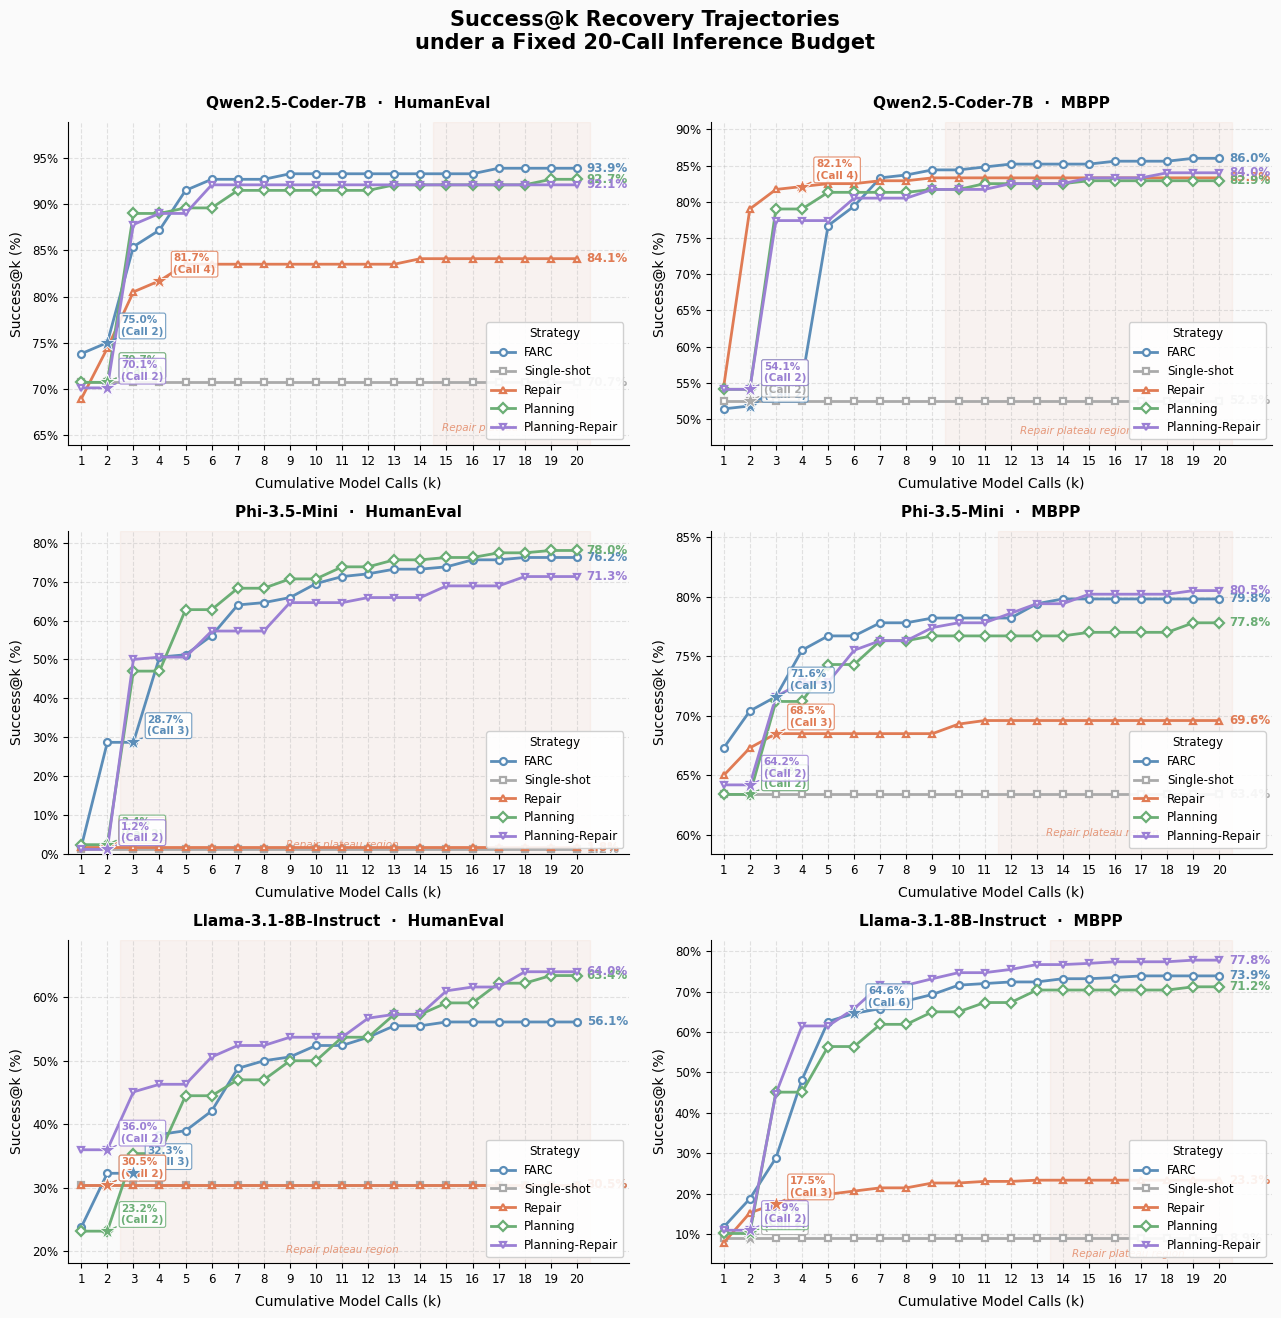

저장 완료: ./archive/success_at_k_panels.png


In [6]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

# ── 데이터 ────────────────────────────────────────────────────────────────
DATA

# ── 스타일 ────────────────────────────────────────────────────────────────
STYLE = {
    "FARC":            {"color": "#5B8DB8", "marker": "o"},
    "Single-shot":     {"color": "#AAAAAA", "marker": "s"},
    "Repair":          {"color": "#E07B54", "marker": "^"},
    "Planning":        {"color": "#6BAE75", "marker": "D"},
    "Planning-Repair": {"color": "#9B7FD4", "marker": "v"},
}

PANEL_LAYOUT = [
    ("Qwen2.5-Coder-7B", "HumanEval"),
    ("Qwen2.5-Coder-7B", "MBPP"),
    ("Phi-3.5-Mini",     "HumanEval"),
    ("Phi-3.5-Mini",     "MBPP"),
    ("Llama-3.1-8B-Instruct",     "HumanEval"),
    ("Llama-3.1-8B-Instruct",     "MBPP"),
]

steps = list(range(1, 21))

# ── Figure ────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(3, 2, figsize=(13, 13), sharey=False, constrained_layout=True)
fig.patch.set_facecolor("#FAFAFA")
fig.suptitle(
    "Success@k Recovery Trajectories\nunder a Fixed 20-Call Inference Budget",
    fontsize=15, fontweight="bold", y=1.01,
)

for idx, (model, dataset) in enumerate(PANEL_LAYOUT):
    row, col = divmod(idx, 2)
    ax = axes[row][col]
    ax.set_facecolor("#FAFAFA")

    strats = DATA[(model, dataset)]

    # y축 범위 자동 계산
    all_vals = [v for vals in strats.values() for v in vals]
    y_min = max(0,   min(all_vals) - 5)
    y_max = min(100, max(all_vals) + 5)

    # Repair plateau 음영
    if "Repair" in strats:
        repair_vals = strats["Repair"]
        plateau_start = next(
            (i + 1 for i in range(1, len(repair_vals)) if repair_vals[i] == repair_vals[-1]),
            len(repair_vals),
        )
        ax.axvspan(plateau_start + 0.5, 20.5, alpha=0.06, color="#E07B54", zorder=1)
        ax.text(
            (plateau_start + 20) / 2, y_min + 1.5,
            "Repair plateau region",
            ha="center", fontsize=7.5, color="#E07B54", alpha=0.75, style="italic",
        )

    # 라인 플롯
    for label, values in strats.items():
        s = STYLE.get(label, {"color": "gray", "marker": "x"})
        ax.plot(
            steps, values,
            color=s["color"],
            linestyle="-",
            linewidth=2.0,
            marker=s["marker"],
            markersize=5,
            markerfacecolor="white",
            markeredgewidth=1.6,
            markeredgecolor=s["color"],
            label=label,
            zorder=3,
        )
        # 라인 끝 최종값 레이블
        ax.annotate(
            f"{values[-1]:.1f}%",
            xy=(20, values[-1]),
            xytext=(7, 0),
            textcoords="offset points",
            va="center",
            fontsize=8.5,
            fontweight="bold",
            color=s["color"],
        )

    # ── plateau 시작점 마커 (상대 변화율 기준: 전체 범위의 5% 이하) ──────────
    val_range = y_max - y_min  # 패널 전체 y 범위
    threshold = val_range * 0.05

    for label, values in strats.items():
        # k=1은 이전 step이 없으므로 k=2(index 1)부터 탐색
        plateau_k = None
        for i in range(1, len(values)):
            if abs(values[i] - values[i - 1]) <= threshold:
                plateau_k = i + 1   # 1-based step
                break

        # 마지막 step이거나 감지 안 되면 스킵
        if plateau_k is None or plateau_k == 20:
            continue

        s = STYLE.get(label, {"color": "gray", "marker": "x"})
        pv = values[plateau_k - 1]

        # ★ 마커
        ax.plot(
            plateau_k, pv,
            marker="*", markersize=12,
            color=s["color"], zorder=5,
            markeredgecolor="white", markeredgewidth=0.6,
        )
        # 레이블 박스
        ax.annotate(
            f"{pv:.1f}%\n(Call {plateau_k})",
            xy=(plateau_k, pv),
            xytext=(10, 12),
            textcoords="offset points",
            fontsize=7.5,
            color=s["color"],
            fontweight="bold",
            arrowprops=dict(arrowstyle="-", color=s["color"], lw=1.0),
            va="center",
            bbox=dict(boxstyle="round,pad=0.2", fc="white",
                      ec=s["color"], alpha=0.85, lw=0.8),
        )

    # 축 설정
    ax.set_xlim(0.5, 22)
    ax.set_ylim(y_min, y_max)
    ax.set_xticks(steps)
    ax.set_xticklabels([str(s) for s in steps], fontsize=8)
    ax.set_xlabel("Cumulative Model Calls (k)", fontsize=10, labelpad=6)
    ax.set_ylabel("Success@k (%)", fontsize=10, labelpad=6)
    ax.set_title(f"{model}  ·  {dataset}", fontsize=11, fontweight="bold", pad=10)
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:.0f}%"))
    ax.grid(True, linestyle="--", alpha=0.35, zorder=0)
    ax.tick_params(axis="both", labelsize=8.5)
    ax.spines[["top", "right"]].set_visible(False)

    ax.legend(
        title="Strategy",
        title_fontsize=8.5,
        fontsize=8.5,
        loc="lower right",
        framealpha=0.9,
        edgecolor="#CCCCCC",
    )

plt.tight_layout()
plt.savefig("./archive/success_at_k_panels.png", dpi=150, bbox_inches="tight")
plt.show()
print("저장 완료: ./archive/success_at_k_panels.png")